# Обучение SegFormer для задачи сегментации повреждений фасада

In [2]:
!pip install -q transformers evaluate datasets albumentations accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.9 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
import evaluate
import albumentations as A
from torch.utils.data import Dataset, DataLoader
from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor, TrainingArguments, Trainer
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
import warnings
import wandb


device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Используем устройство: {device}")
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
warnings.filterwarnings('ignore')

Используем устройство: cuda


## 1. Настройка путей и классов

In [4]:
# ПУТИ В KAGGLE
DATASET_PATH = '/kaggle/input/datasets/neuromant/facade-damage-seg-301-imgs-v2/unified_dataset'  
IMAGES_DIR = os.path.join(DATASET_PATH, 'Images')          # Папка с исходными .jpg
MASKS_DIR = os.path.join(DATASET_PATH, 'Masks')            # Папка с экспортированными из CVAT масками (RGB)

# Маппинг классов
CLASS_MAPPING = {
    0: "background",
    1: "coating_deterioration",
    2: "cracks",
    3: "masonry_degradation",
    4: "moisture_bio_damage",
    5: "vandalism",
    255: "Ignored" 
}
id2label = CLASS_MAPPING
label2id = {v: k for k, v in id2label.items()}

cvat_colors_rgb = {
    "background": [0, 0, 0],
    "coating_deterioration": [54, 21, 217],
    "cracks": [250, 50, 183],
    "masonry_degradation": [42, 125, 209],
    "moisture_bio_damage": [38, 221, 98],
    "vandalism": [222, 28, 123],
    "Ignored": [221, 255, 51]
}

## 2. Подготовка Данных (Конвертация RGB-масок в Индексные)

In [5]:
from glob import glob

# Прописываем пути к готовым папкам train и val
TRAIN_IMAGES_DIR = os.path.join(DATASET_PATH, 'images', 'train')
TRAIN_MASKS_DIR = os.path.join(DATASET_PATH, 'masks', 'train')

VAL_IMAGES_DIR = os.path.join(DATASET_PATH, 'images', 'val')
VAL_MASKS_DIR = os.path.join(DATASET_PATH, 'masks', 'val')

train_pairs = []
for mask_path in glob(os.path.join(TRAIN_MASKS_DIR, "*.png")):
    filename = os.path.basename(mask_path)
    img_path = os.path.join(TRAIN_IMAGES_DIR, filename)
    if os.path.exists(img_path):
        train_pairs.append({"image": img_path, "mask": mask_path})

val_pairs = []
for mask_path in glob(os.path.join(VAL_MASKS_DIR, "*.png")):
    filename = os.path.basename(mask_path)
    img_path = os.path.join(VAL_IMAGES_DIR, filename)
    if os.path.exists(img_path):
        val_pairs.append({"image": img_path, "mask": mask_path})

print(f"Обучающая выборка: {len(train_pairs)}")
print(f"Валидационная выборка: {len(val_pairs)}")


Обучающая выборка: 240
Валидационная выборка: 61


## 4. PyTorch Dataset & Augmentations

In [6]:
class DamageSegmentationDataset(Dataset):
    def __init__(self, dataset_pairs, transform=None):
        self.dataset_pairs = dataset_pairs
        self.transform = transform
        # ImageProcessor нормирует картинки под SegFormer
        self.processor = SegformerImageProcessor.from_pretrained("nvidia/mit-b2")

    def __len__(self):
        return len(self.dataset_pairs)

    def __getitem__(self, idx):
        pair = self.dataset_pairs[idx]
        
        # Считываем изображение (RGB для Albumentations)
        image = cv2.imread(pair["image"])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Считываем индексную маску
        mask = cv2.imread(pair["mask"], cv2.IMREAD_GRAYSCALE)
        
        # Применяем аугментации
        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        # Подготовка под HuggingFace Segformer Processor
        # Он занимается ресайзом и нормализацией (ImageNet norm)
        # HuggingFace ожидает PIL картинку
        inputs = self.processor(images=Image.fromarray(image), segmentation_maps=mask, return_tensors="pt")
        
        # Убираем лишнюю размерность batch, созданную процессором
        inputs = {k: v.squeeze() for k, v in inputs.items()}
        
        return inputs

# Аугментации на тренировку (чуть добавляем вариативности)
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
])

# Валидации ессно без аугментаций
val_transform = None

train_dataset = DamageSegmentationDataset(train_pairs, transform=train_transform)
val_dataset = DamageSegmentationDataset(val_pairs, transform=val_transform)

preprocessor_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

## 5. Вычисление Весов Классов (Loss Weights)

У нас сильный дисбаланс, поэтому мы вычислим веса для CrossEntropyLoss, чтобы штрафовать редкие классы сильнее.

In [7]:
# Веса рассчитаны скриптом на всем объединенном датасете (Median Frequency Balancing)
weights = [0.0622, 0.5067, 6.6031, 4.8248, 0.5578, 8.7833]

class_weights_tensor = torch.tensor(weights, dtype=torch.float).to(device)
print("Веса классов для CrossEntropyLoss:")
for i, w in enumerate(weights):
    print(f"Класс {id2label[i]}: {w:.4f}")

Веса классов для CrossEntropyLoss:
Класс background: 0.0622
Класс coating_deterioration: 0.5067
Класс cracks: 6.6031
Класс masonry_degradation: 4.8248
Класс moisture_bio_damage: 0.5578
Класс vandalism: 8.7833


## Инициализация wandb

In [ ]:
wandb.login() # вставить API ключ от аккаунта W&B
wandb.init(project="facade-damage-segformer", name="5_classes_run1")

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: rimedheart (rimedheart-personal-use) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## 6. Инициализация Модели и Метрик

Используем кастомный класс `WeightedTrainer`, чтобы передать наши веса в функцию потерь.

In [ ]:
from torch import nn

# Кастомный Trainer с весами
class ClassWeightsTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        
        # Скейл масок к размеру логитов (1/4 от оригинального изображения)
        upsampled_logits = nn.functional.interpolate(
            logits, 
            size=labels.shape[-2:], 
            mode="bilinear", 
            align_corners=False
        )
        
        # ignore_index=255 значит, что лосс не считается на пикселях класса Ignored!
        loss_fct = nn.CrossEntropyLoss(weight=class_weights_tensor, ignore_index=255)
        loss = loss_fct(upsampled_logits, labels)
        
        return (loss, outputs) if return_outputs else loss


# Загружаем метрику mIoU
metric = evaluate.load("mean_iou")

def compute_metrics(eval_pred):
    with torch.no_grad():
        logits, labels = eval_pred
        logits_tensor = torch.from_numpy(logits)
        
        # Скейл логитов до оригинального размера
        logits_tensor = nn.functional.interpolate(
            logits_tensor,
            size=labels.shape[-2:],
            mode="bilinear",
            align_corners=False,
        ).argmax(dim=1)
        
        pred_labels = logits_tensor.detach().cpu().numpy()
        
        metrics = metric.compute(
            predictions=pred_labels,
            references=labels,
            num_labels=len(id2label) - 1, 
            ignore_index=255,
            reduce_labels=False,
        )
        
        # безопасное извлечение метрик (перевод всего в float)
        safe_metrics = {}
        
        # Основная метрика mIoU
        if "mean_iou" in metrics:
            safe_metrics["mean_iou"] = float(metrics["mean_iou"])
            
        if "mean_accuracy" in metrics:
            safe_metrics["mean_accuracy"] = float(metrics["mean_accuracy"])
            
        if "overall_accuracy" in metrics:
            safe_metrics["overall_accuracy"] = float(metrics["overall_accuracy"])
        
        # Вытаскиваем IoU по каждому классу отдельно
        if "per_category_iou" in metrics:
            # Превращаем numpy array в обычный питоновский list
            per_category_iou = metrics["per_category_iou"]
            if isinstance(per_category_iou, np.ndarray):
                per_category_iou = per_category_iou.tolist()
                
            for i, val in enumerate(per_category_iou):
                if i < len(id2label) - 1:
                    # Обязательно кастуем в float
                    safe_metrics[f"iou_{id2label[i]}"] = float(val) if not np.isnan(val) else 0.0
            
        return safe_metrics


# Загрузка модели (Берем ImageNet encoder B2)
model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/mit-b2",
    num_labels=len(id2label) - 1, # 6 рабочих классов (0-5)
    id2label={k: v for k,v in id2label.items() if k != 255},
    label2id={v: k for k,v in id2label.items() if k != 255},
    ignore_mismatched_sizes=True # Важно, т.к. мы меняем голову под свои 6 классов
)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/99.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b2
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.bias                               | UNEXPECTED | 
classifier.weight                             | UNEXPECTED | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different ta

model.safetensors:   0%|          | 0.00/98.9M [00:00<?, ?B/s]

## 7. Параметры обучения

Ставим 30-50 эпох, так как датасет небольшой. С оптимизатором AdamW и Cosine расписанием, чтобы  SegFormer быстро выучился.

In [ ]:
training_args = TrainingArguments(
    output_dir="/kaggle/working/segformer-b2-facade-damage",
    report_to="wandb",
    learning_rate=6e-5,
    num_train_epochs=50,
    
    per_device_train_batch_size=4,  # Возьмем батч поменьше
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=2,  # Накапливаем градиенты 
    
    dataloader_num_workers=0,       # отключаем многопроцессорность загрузки (спасает от зависаний OpenCV)
    eval_accumulation_steps=1,      # Спасает от переполнения оперативной памяти при валидации
    
    eval_strategy="epoch",
    save_strategy="epoch",          
    save_total_limit=1,             # Храним только 1 лучший файл весов, чтобы не забить жесткий диск
    load_best_model_at_end=True,    
    metric_for_best_model="mean_iou",
)



trainer = ClassWeightsTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)


In [ ]:
# training_args = TrainingArguments(
#     output_dir="/kaggle/working/segformer-b2-facade-damage",
#     report_to="wandb",
#     learning_rate=6e-5,
#     num_train_epochs=50,
#     per_device_train_batch_size=8, # Кажется, неплохо влезло на GPU
#     per_device_eval_batch_size=8,
#     save_total_limit=3,
#     eval_strategy="epoch",
#     save_strategy="epoch",
#     logging_steps=10,
#     eval_steps=10,
#     remove_unused_columns=False,
#     push_to_hub=False,
#     load_best_model_at_end=True,
#     metric_for_best_model="mean_iou",
# )

# trainer = ClassWeightsTrainer(
#     model=model,
#     args=training_args,
#     train_dataset=train_dataset,
#     eval_dataset=val_dataset,
#     compute_metrics=compute_metrics,
# )

## 8. Запуск Обучения

In [11]:
print("Погнали учиться!")
trainer.train()

Погнали учиться!


Epoch,Training Loss,Validation Loss,Mean Iou,Mean Accuracy,Overall Accuracy,Iou Background,Iou Coating Deterioration,Iou Cracks,Iou Masonry Degradation,Iou Moisture Bio Damage,Iou Vandalism
1,No log,1.201473,0.161464,0.599121,0.428662,0.407930,0.231928,0.018159,0.040773,0.182272,0.087724
2,No log,0.900584,0.248118,0.691831,0.585724,0.555912,0.292397,0.034887,0.103034,0.271125,0.231355
3,No log,0.859772,0.271244,0.669909,0.548518,0.495213,0.311688,0.100825,0.256254,0.210797,0.252686
4,No log,0.802487,0.285428,0.722029,0.671064,0.652384,0.355775,0.094918,0.123023,0.296902,0.189569
5,No log,0.817521,0.297004,0.716206,0.654266,0.625943,0.336688,0.123902,0.175735,0.287376,0.232382
6,No log,0.860756,0.319669,0.694766,0.686400,0.660436,0.334649,0.090258,0.229975,0.341975,0.260720
7,No log,0.655593,0.359298,0.781439,0.745518,0.736179,0.399826,0.108830,0.205017,0.368769,0.337169
8,No log,0.704733,0.380206,0.751626,0.775045,0.766665,0.412060,0.149167,0.237910,0.411985,0.303447
9,No log,0.729686,0.382906,0.744801,0.758470,0.743907,0.410178,0.140368,0.280400,0.383912,0.338668
10,No log,0.783047,0.397645,0.734602,0.770808,0.763072,0.405671,0.115112,0.337502,0.394276,0.370237


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1500, training_loss=0.4441026204427083, metrics={'train_runtime': 3536.9122, 'train_samples_per_second': 3.393, 'train_steps_per_second': 0.424, 'total_flos': 1.548711993802752e+18, 'train_loss': 0.4441026204427083, 'epoch': 50.0})

## 9. Анализ результатов

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import random
import torch
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import cv2
from tqdm.auto import tqdm

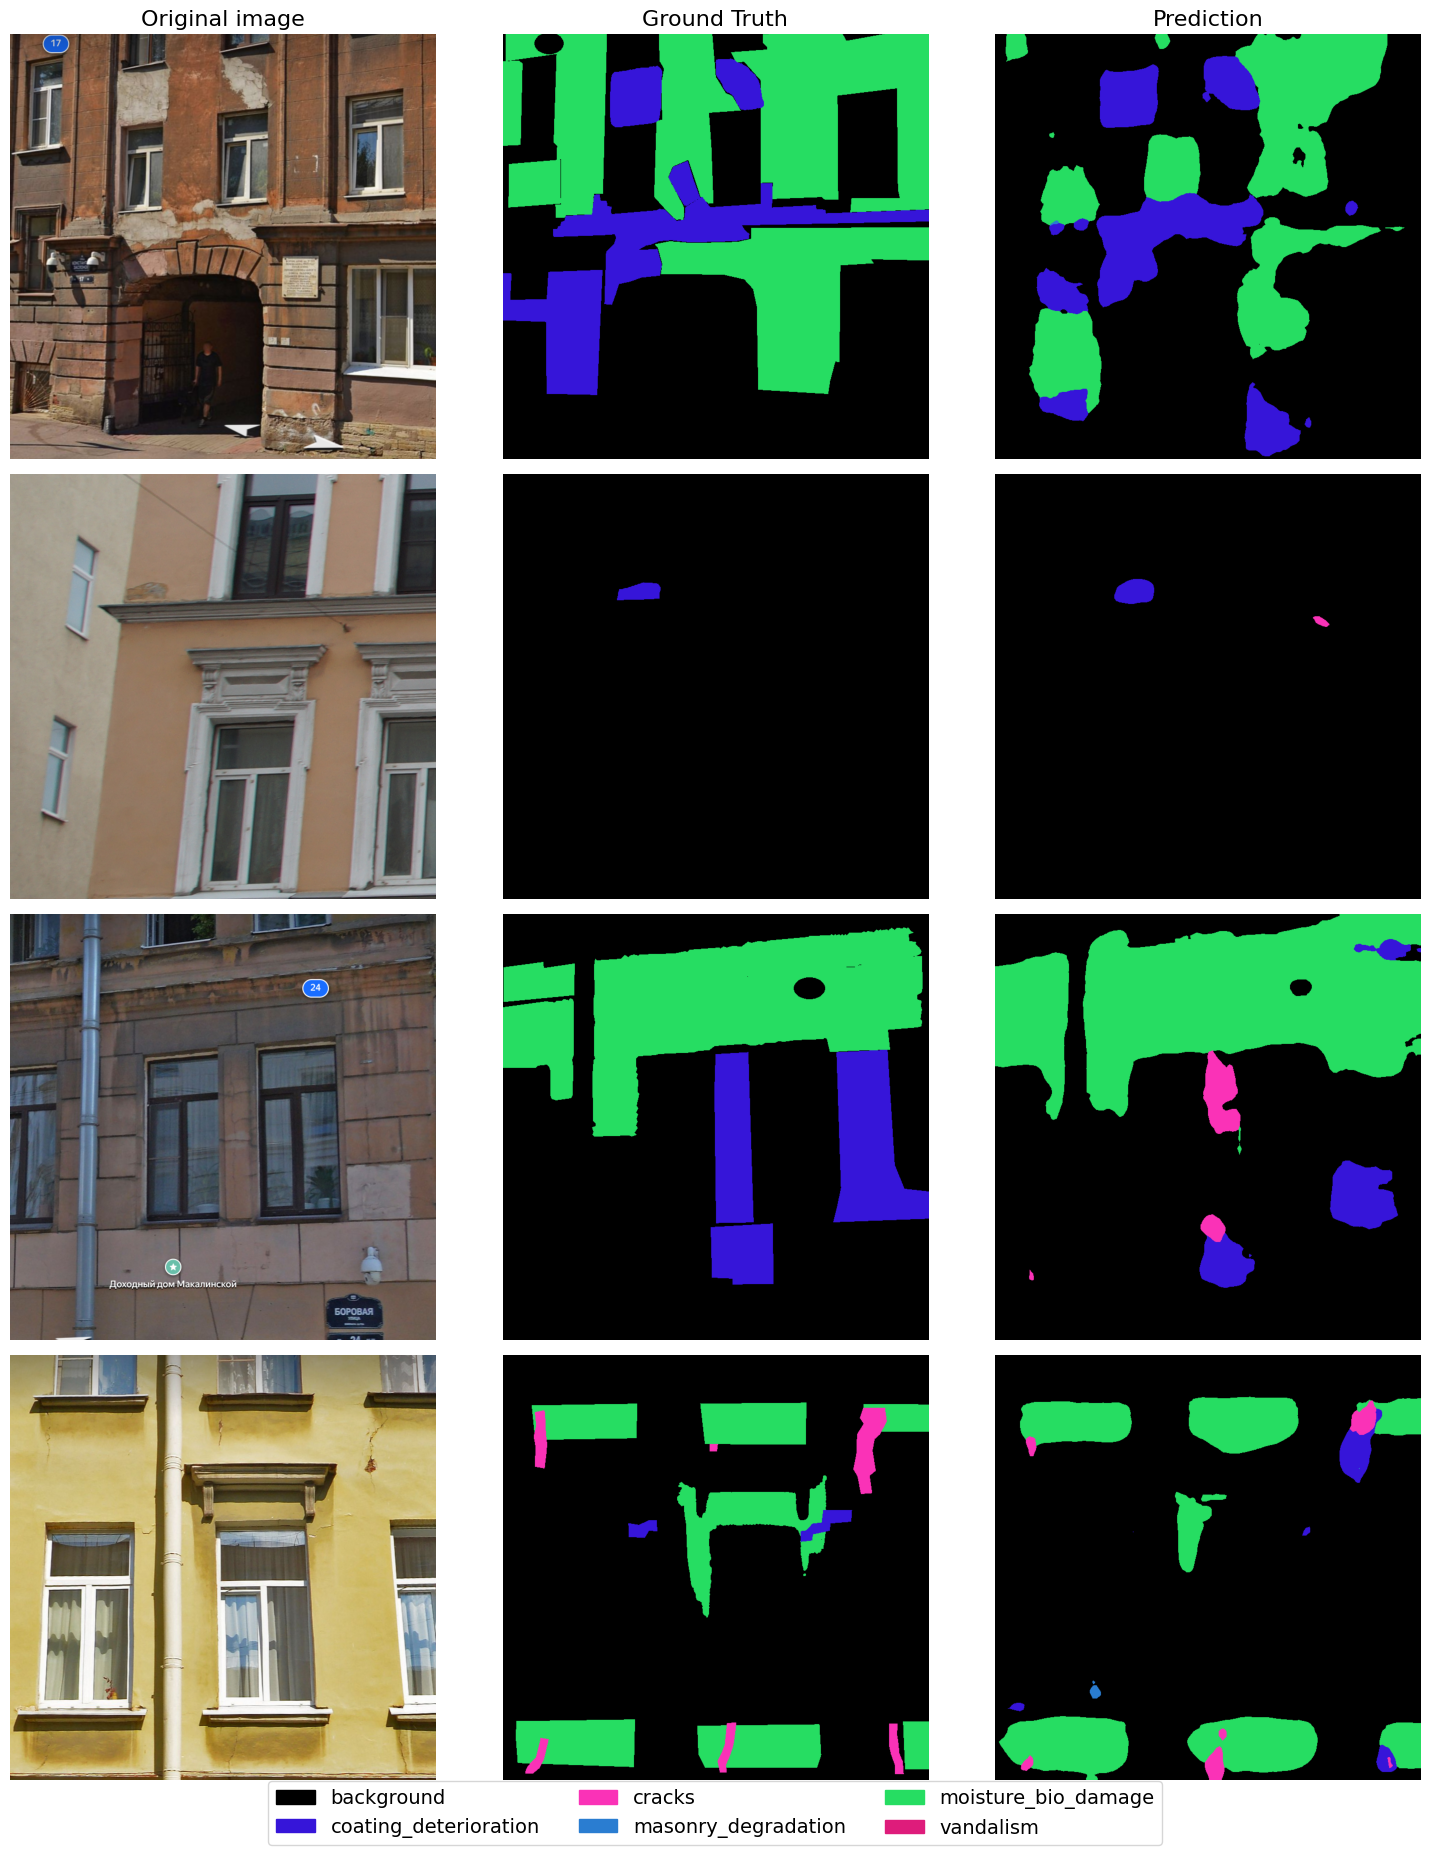

In [13]:
# Цветовая палитра (RGB)
color_map = {
    0: (0, 0, 0),         # background
    1: (54, 21, 217),     # coating_deterioration
    2: (250, 50, 183),    # cracks
    3: (42, 125, 209),    # masonry_degradation
    4: (38, 221, 98),     # moisture_bio_damage
    5: (222, 28, 123)     # vandalism
}

def label_to_color_image(label_mask):
    color_img = np.zeros((label_mask.shape[0], label_mask.shape[1], 3), dtype=np.uint8)
    for class_id, color in color_map.items():
        color_img[label_mask == class_id] = color
    return color_img

# Выбираем 4 случайных патча из валидации
sample_indices = random.sample(range(len(val_pairs)), 4)

fig, axes = plt.subplots(4, 3, figsize=(15, 20))
axes[0, 0].set_title("Original image", fontsize=16)
axes[0, 1].set_title("Ground Truth", fontsize=16)
axes[0, 2].set_title("Prediction", fontsize=16)

model.eval() 

with torch.no_grad():
    for i, idx in enumerate(sample_indices):
        pair = val_pairs[idx]
        
        # Загрузка оригинала для отрисовки
        orig_img = cv2.imread(pair["image"])
        orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
        
        # Подготовка тензора для модели 
        # (val_dataset берет ImageProcessor, который уже нормализует картинку)
        inputs = val_dataset[idx]
        input_tensor = inputs["pixel_values"].unsqueeze(0).to(device)
        
        # Истинная маска
        gt_mask = cv2.imread(pair["mask"], cv2.IMREAD_GRAYSCALE)
        
        # Инференс только что обученной модели
        outputs = model(pixel_values=input_tensor)
        logits = outputs.logits
        
        # Растягиваем логиты (которые в 4 раза меньше) обратно до 800x800
        upsampled_logits = torch.nn.functional.interpolate(
            logits, 
            size=orig_img.shape[:2], 
            mode="bilinear", 
            align_corners=False
        )
        
        # Получаем итоговую маску предсказания
        pred_mask = upsampled_logits.argmax(dim=1).squeeze().cpu().numpy()
        
        # Раскрашиваем маски
        gt_color = label_to_color_image(gt_mask)
        pred_color = label_to_color_image(pred_mask)
        
        # Выводим на экран
        axes[i, 0].imshow(orig_img)
        axes[i, 0].axis("off")
        axes[i, 1].imshow(gt_color)
        axes[i, 1].axis("off")
        axes[i, 2].imshow(pred_color)
        axes[i, 2].axis("off")

# Легенда
patches = [mpatches.Patch(color=np.array(color)/255.0, label=CLASS_MAPPING[idx]) 
           for idx, color in color_map.items()]
fig.legend(handles=patches, loc='lower center', ncol=3, bbox_to_anchor=(0.5, 0.02), fontsize=14)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()


  0%|          | 0/61 [00:00<?, ?it/s]

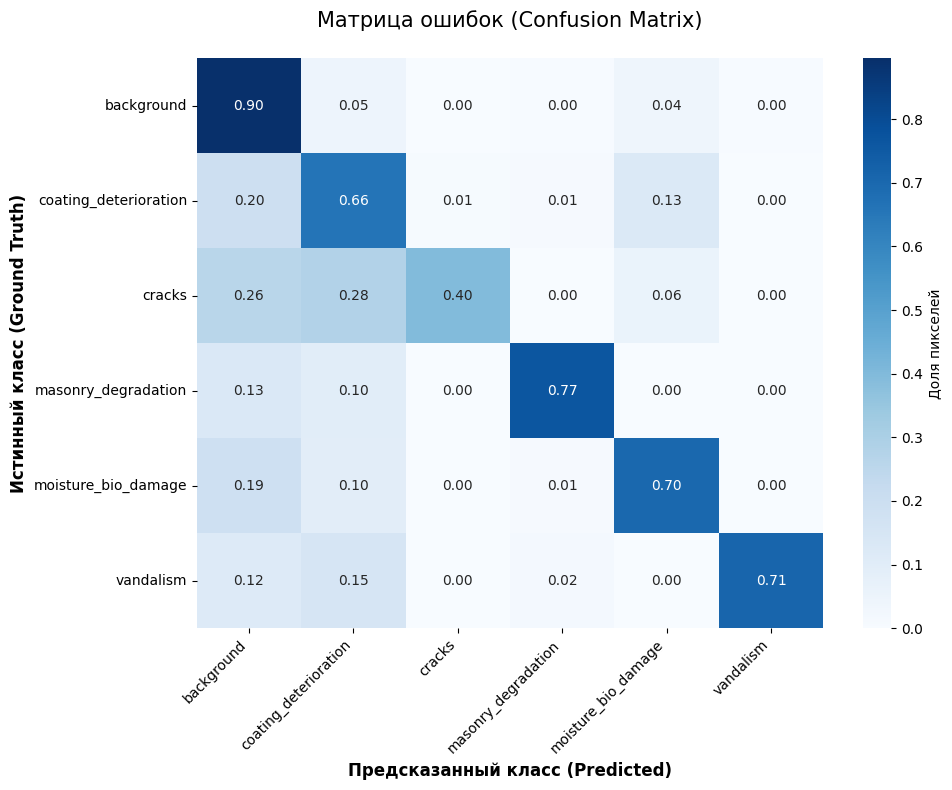


 IoU по классам на всей валидационной выборке
background               : 0.8480
coating_deterioration    : 0.4623
cracks                   : 0.2064
masonry_degradation      : 0.4018
moisture_bio_damage      : 0.4661
vandalism                : 0.4864
----------------------------------
Mean IoU                 : 0.4785


In [14]:
# Задаем только рабочие классы
working_classes = [0, 1, 2, 3, 4, 5]
num_classes = len(working_classes)
class_names = [CLASS_MAPPING[i] for i in working_classes]

# Инициализируем матрицу 6x6
total_cm = np.zeros((num_classes, num_classes), dtype=np.int64)

model.eval()

# Прогон валидационной выборки для матрицы ошибок
with torch.no_grad():
    for idx in tqdm(range(len(val_pairs))):
        pair = val_pairs[idx]
        
        # Загрузка истинной маски (GT)
        gt_mask = cv2.imread(pair["mask"], cv2.IMREAD_GRAYSCALE)
        
        # Подготовка тензора
        inputs = val_dataset[idx]
        input_tensor = inputs["pixel_values"].unsqueeze(0).to(device)
        
        # Инференс
        outputs = model(pixel_values=input_tensor)
        logits = outputs.logits
        
        # Ресайз предсказания (до 800x800)
        upsampled_logits = torch.nn.functional.interpolate(
            logits, 
            size=gt_mask.shape[:2], 
            mode="bilinear", 
            align_corners=False
        )
        pred_mask = upsampled_logits.argmax(dim=1).squeeze().cpu().numpy()
        
        # Вытягиваем маски в 1D массивы
        y_true = gt_mask.flatten()
        y_pred = pred_mask.flatten()
        
        # Строим матрицу ТОЛЬКО по нужным нам лейблам (0..5)
        # Все случайные пиксели со значением 255 просто проигнорируем
        cm = confusion_matrix(y_true, y_pred, labels=working_classes)
        total_cm += cm

# Визуализация
# Нормализуем по строкам (доля предсказанных пикселей)
cm_normalized = total_cm.astype('float') / total_cm.sum(axis=1)[:, np.newaxis]
cm_normalized = np.nan_to_num(cm_normalized)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized, 
    annot=True,              
    fmt=".2f",               
    cmap="Blues",            
    xticklabels=class_names, 
    yticklabels=class_names,
    cbar_kws={'label': 'Доля пикселей'}
)

plt.title("Матрица ошибок (Confusion Matrix)\n", fontsize=15)
plt.ylabel('Истинный класс (Ground Truth)', fontsize=12, fontweight='bold')
plt.xlabel('Предсказанный класс (Predicted)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Доп. расчет итоговых метрик IoU на всей выборке 
print("\n IoU по классам на всей валидационной выборке")
intersection = np.diag(total_cm)
ground_truth_set = total_cm.sum(axis=1)
predicted_set = total_cm.sum(axis=0)
union = ground_truth_set + predicted_set - intersection

ious = intersection / union.astype(np.float32)

for i, class_name in enumerate(class_names):
    print(f"{class_name.ljust(25)}: {ious[i]:.4f}")
print("-" * 34)
print(f"Mean IoU                 : {np.nanmean(ious):.4f}")


## 9. Анализ результатов после повторного инференса на валидационной выборке

Загружаем ранее обученную модель

In [ ]:
# MODEL_PATH = '/kaggle/input/models/neuromant/segformer-b2-facade-damage/transformers/default/1/segformer_weights' 

# print("Загрузка процессора и модели...")
# processor = SegformerImageProcessor.from_pretrained("nvidia/mit-b2")
# model = SegformerForSemanticSegmentation.from_pretrained(MODEL_PATH)
# model.to(device)
# model.eval()

In [ ]:
import seaborn as sns 
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import DataLoader
from PIL import Image
import cv2 

Функция для сбора предсказаний модели

  Эта функция пройдет по валидационному набору данных и соберет все истинные маски и предсказанные моделью маски. Она
  также сохранит несколько примеров для визуализации.

In [ ]:
def collect_predictions(model, val_dataset, device, processor, num_samples_to_visualize=5):
    """
    Собирает истинные и предсказанные маски для всего валидационного набора данных,
    а также несколько примеров для визуализации.

    Параметры:
        model: Обученная модель SegFormer.
        val_dataset: Объект PyTorch Dataset для валидационных данных.
        device: Устройство, на котором будет выполняться инференс ('cuda' или 'cpu').
        processor: SegformerImageProcessor, используемый для предобработки изображений.
        num_samples_to_visualize: Количество случайных примеров для сохранения для визуализации.

    Возвращает:
        all_true_masks_flat: Одномерный массив всех истинных пиксельных меток.
        all_pred_masks_flat: Одномерный массив всех предсказанных пиксельных меток.
        sample_images: Список оригинальных изображений для визуализации.
        sample_true_masks: Список истинных масок для визуализации.
        sample_pred_masks: Список предсказанных масок для визуализации.
    """
    model.eval() # Переводим модель в режим оценки
    model.to(device)

    val_dataloader = DataLoader(val_dataset, batch_size=1, shuffle=False) # Используем batch_size=1 для простоты

    all_true_masks_flat = []
    all_pred_masks_flat = []

    sample_images = []
    sample_true_masks = []
    sample_pred_masks = []

    # Для отслеживания, сколько примеров для визуализации уже собрано
    visualized_count = 0

    print("Собираем предсказания для валидационного набора данных...")
    with torch.no_grad(): 
        for i, batch in tqdm(enumerate(val_dataloader), total=len(val_dataloader)):
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(pixel_values=pixel_values)
            logits = outputs.logits

            # Изменяем размер логитов до размера оригинальной маски
            upsampled_logits = torch.nn.functional.interpolate(
                logits,
                size=labels.shape[-2:], # Размер истинной маски
                mode="bilinear",
                align_corners=False,
            )

            # Получаем предсказанные классы
            pred_labels = upsampled_logits.argmax(dim=1)

            # Перемещаем на CPU и конвертируем в numpy для дальнейшей обработки
            true_mask_np = labels.cpu().numpy().flatten()
            pred_mask_np = pred_labels.cpu().numpy().flatten()

            all_true_masks_flat.extend(true_mask_np)
            all_pred_masks_flat.extend(pred_mask_np)

            # Сохраняем несколько примеров для визуализации
            if visualized_count < num_samples_to_visualize:                 
                # Для получения оригинального изображения, нам нужно обратиться к исходному датасету
                # val_dataset[i] возвращает уже обработанные данные, поэтому нужно
                # получить оригинальный путь к изображению из val_dataset.dataset_pairs[i]
                original_image_path = val_dataset.dataset_pairs[i]["image"]
                original_image = cv2.imread(original_image_path)
                original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB) # Переводим в RGB

                sample_images.append(original_image)
                sample_true_masks.append(labels.cpu().squeeze().numpy())
                sample_pred_masks.append(pred_labels.cpu().squeeze().numpy())
                visualized_count += 1

    return np.array(all_true_masks_flat), np.array(all_pred_masks_flat), sample_images, sample_true_masks, sample_pred_masks

3. Функции для анализа метрик (Матрица ошибок и метрики по классам)


  Этот блок кода будет использовать собранные маски для вычисления и отображения матрицы ошибок, а также для вывода
  детальных метрик по каждому классу.

In [ ]:
def analyze_metrics(all_true_masks_flat, all_pred_masks_flat, id2label, ignore_index=255):
    """
    Вычисляет и отображает матрицу ошибок, а также метрики Precision, Recall, F1-score и IoU
    для каждого класса.

    Параметры:
        all_true_masks_flat: Одномерный массив всех истинных пиксельных меток.
        all_pred_masks_flat: Одномерный массив всех предсказанных пиксельных меток.
        id2label: Словарь, сопоставляющий ID класса его названию.
        ignore_index: Индекс класса, который следует игнорировать при расчетах.
    """
    # Фильтруем пиксели, которые должны быть проигнорированы
    valid_pixels_mask = (all_true_masks_flat != ignore_index)
    true_labels_filtered = all_true_masks_flat[valid_pixels_mask]
    pred_labels_filtered = all_pred_masks_flat[valid_pixels_mask]

    # Определяем активные классы (исключая игнорируемый)
    active_class_ids = sorted([k for k in id2label.keys() if k != ignore_index])
    active_class_names = [id2label[k] for k in active_class_ids]
    num_active_classes = len(active_class_ids)

    print("\nМатрица ошибок")
    cm = confusion_matrix(true_labels_filtered, pred_labels_filtered, labels=active_class_ids)

    # Нормализуем матрицу ошибок для отображения долей
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    cm_normalized = np.nan_to_num(cm_normalized) # Заменяем NaN на 0, если есть классы без истинных пикселей

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=active_class_names, yticklabels=active_class_names)
    plt.title("Нормализованная матрица ошибок (Confusion Matrix)")
    plt.xlabel("Предсказанный класс")
    plt.ylabel("Истинный класс")
    plt.show()

    print("\nОтчет по классификации (Precision, Recall, F1-score)")
    print(classification_report(true_labels_filtered, pred_labels_filtered,
                                labels=active_class_ids, target_names=active_class_names, zero_division=0))

    print("\n-IoU по классам (Intersection over Union)")
    # Вычисляем IoU из матрицы ошибок
    iou_per_class = []
    for i in range(num_active_classes):
        true_positives = cm[i, i]
        false_positives = np.sum(cm[:, i]) - true_positives
        false_negatives = np.sum(cm[i, :]) - true_positives

        denominator = true_positives + false_positives + false_negatives
        iou = true_positives / denominator if denominator > 0 else 0
        iou_per_class.append(iou)
        print(f"Класс '{active_class_names[i]}': {iou:.4f}")

  4. Функция для визуализации предсказаний


Визуально оценим качество сегментации, отображая оригинальное изображение, истинную маску и предсказанную маску.

In [ ]:
def visualize_predictions(sample_images, sample_true_masks, sample_pred_masks, id2label, cvat_colors_rgb):
    """
    Визуализирует оригинальные изображения, истинные маски и предсказанные маски.

    Параметры:
        sample_images: Список оригинальных изображений (numpy array, RGB).
        sample_true_masks: Список истинных масок (numpy array, индексы классов).
        sample_pred_masks: Список предсказанных масок (numpy array, индексы классов).
        id2label: Словарь, сопоставляющий ID класса его названию.
        cvat_colors_rgb: Словарь, сопоставляющий название класса его RGB цвету.
    """
    def get_colored_mask(mask, id2label, cvat_colors_rgb):
        """Преобразует индексную маску в цветную RGB маску."""
        h, w = mask.shape
        colored_mask = np.zeros((h, w, 3), dtype=np.uint8)
        for class_id, class_name in id2label.items():
            if class_id == 255: # Игнорируем класс, если он не должен быть визуализирован
                continue
            color = cvat_colors_rgb.get(class_name, [0, 0, 0]) # Цвет по умолчанию черный
            colored_mask[mask == class_id] = color
        return colored_mask

    print("\nВизуализация предсказаний")
    for i in range(len(sample_images)):
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))

        # Оригинальное изображение
        axes[0].imshow(sample_images[i])
        axes[0].set_title("Оригинальное изображение")
        axes[0].axis("off")

        # Истинная маска
        true_colored_mask = get_colored_mask(sample_true_masks[i], id2label, cvat_colors_rgb)
        axes[1].imshow(true_colored_mask)
        axes[1].set_title("Истинная маска")
        axes[1].axis("off")

        # Предсказанная маска
        pred_colored_mask = get_colored_mask(sample_pred_masks[i], id2label, cvat_colors_rgb)
        axes[2].imshow(pred_colored_mask)
        axes[2].set_title("Предсказанная маска")
        axes[2].axis("off")

        plt.tight_layout()
        plt.show()

In [ ]:
# Собираем предсказания
all_true_masks_flat, all_pred_masks_flat, sample_images, sample_true_masks, sample_pred_masks = \
    collect_predictions(model, val_dataset, device, processor, num_samples_to_visualize=5)

# Анализируем метрики
analyze_metrics(all_true_masks_flat, all_pred_masks_flat, id2label, ignore_index=255)

# Визуализируем предсказания
visualize_predictions(sample_images, sample_true_masks, sample_pred_masks, id2label, cvat_colors_rgb)